In [1]:
import pandas as pd
import os
import numpy as np

from sqlalchemy import create_engine


In [2]:
data_project = pd.read_csv('../data/raw/oss_scorecard_projects.csv')

In [3]:
# If you want to extract specific metrics into separate columns:
data_project['criticality_score'] = data_project['metadata'].str.extract(r'criticality_score:([\d.]+)')

# Convert to numeric if needed
data_project['criticality_score'] = pd.to_numeric(data_project['criticality_score'], errors='coerce')

In [4]:
df_filtered = data_project[
    ~((data_project['criticality_score'].isna() | (data_project['criticality_score'] == 0))) &
    data_project['metadata'].notna()
]

In [ ]:
user=os.getenv("ECOSYSTEMS_DB_USER")
password = os.getenv("ECOSYSTEMS_DB_PASSWORD")
server = os.getenv("ECOSYSTEMS_DB_SERVER")

engine = create_engine(
        f"postgresql+psycopg2://{user}:{password}@{server}:5432/ecosystems_data_collection"
    )

In [6]:
engine.connect()

# get table "repo_names" from the database in engine

repo_names = pd.read_sql_table("repo_names", engine)

In [7]:
repo_names["repo_group_id"].value_counts()

repo_group_id
102    69
104    29
105    24
101    10
Name: count, dtype: int64

In [8]:
# remove "https://" from url of repo_names
repo_names['repo'] = repo_names['url'].str.replace('https://', '', regex=False)
#  join with df_filtered on repo column. 
df_final = df_filtered.merge(repo_names[['repo', 'repo_group_id']], on='repo', 
                             how='left')
# create column treated with 1 if repo_group_id is not null else 0
df_final['treated'] = df_final['repo_group_id'].apply(lambda x: 1 if pd.notnull(x) else 0)

In [9]:
df_final[df_final['treated'] == 1]["repo_group_id"].value_counts()  

repo_group_id
101.0    4
102.0    4
105.0    1
104.0    1
Name: count, dtype: int64

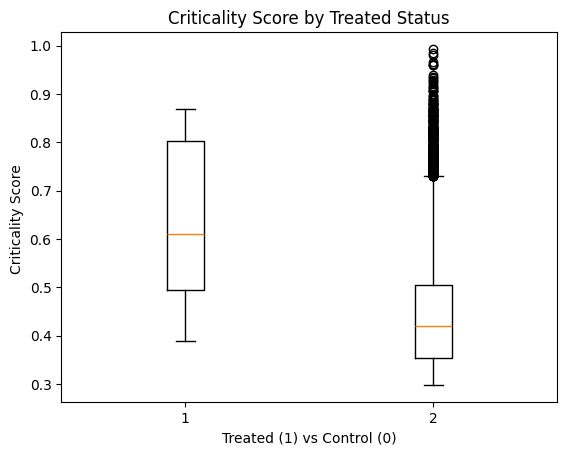

In [10]:
# boxplot of criticality_score by treated or not treated
import matplotlib.pyplot as plt 
plt.boxplot([df_final[df_final['treated'] == 1]['criticality_score'], df_final[df_final['treated'] == 0]['criticality_score']])
plt.title('Criticality Score by Treated Status')
plt.xlabel('Treated (1) vs Control (0)')
plt.ylabel('Criticality Score ')
plt.show()


In [11]:
min_criticality_score_treated = df_final[df_final['treated'] == 1]['criticality_score'].min()
max_criticality_score_treated = df_final[df_final['treated'] == 1]['criticality_score'].max()

df_final = df_final[
    (df_final['criticality_score'] >= min_criticality_score_treated) &
    (df_final['criticality_score'] <= max_criticality_score_treated)
]


In [12]:
# add https:// to repo column
df_final['repository_url'] = 'https://' + df_final['repo']
#drop column 'repo' 
df_final['repo_group'] = 202

In [13]:
df_final.to_csv('../data/proc/oss_scorecard_projects_matched.csv', index=False)
#store as .txt with repository_url separated with repo_group by a comma
df_final[['repository_url', 'repo_group']].to_csv('../data/proc/oss_scorecard_projects_matched.txt', index=False, header=False)